In [1]:
import pandas as pd
import numpy as np

In [2]:
def load_csv_with_masked_data(file_path):

    # Load the CSV file into a DataFrame
    df = pd.read_csv(file_path)
    return df

In [3]:
masked_df=load_csv_with_masked_data('data/out/predictive_masking/centaur-8B/singles/masking_model_83811.csv')

In [4]:
original_df=load_csv_with_masked_data('data/out/predictive_masking/centaur-8B/singles/model_83811.csv')

In [5]:
original_df.head()

,trial_num,prompt,model_choice,human_choice,reward,cumulative_reward,log_likelihood
0,0,"In this task, you have to repeatedly choose be...",U,U,1,1,-0.574219
1,1,"In this task, you have to repeatedly choose be...",P,P,0,1,-0.519531
2,2,"In this task, you have to repeatedly choose be...",U,U,1,2,-0.227539
3,3,"In this task, you have to repeatedly choose be...",U,P,1,3,-0.757812
4,4,"In this task, you have to repeatedly choose be...",U,U,1,4,-0.476562


In [22]:
masked_df.head(100)

,masked_position,original_token,prob_U_masked,prob_P_masked,delta_U,delta_P,trial_num,model_id
0,0,In,0.562500,0.437500,0.000000,0.000000,0,83811
1,1,this,0.531250,0.468750,-0.031250,0.031250,0,83811
2,2,task,0.531250,0.468750,-0.031250,0.031250,0,83811
3,3,",",0.531250,0.468750,-0.031250,0.031250,0,83811
4,4,you,0.531250,0.468750,-0.031250,0.031250,0,83811
...,...,...,...,...,...,...,...,...
95,95,1,0.531250,0.468750,-0.031250,0.031250,0,83811
96,96,:,0.531250,0.468750,-0.031250,0.031250,0,83811
97,97,You,0.531250,0.468750,-0.031250,0.031250,0,83811
98,98,press,0.433594,0.558594,-0.128906,0.121094,0,83811


In [11]:
# Find the token with the greatest absolute change in prob_U_masked for each trial
max_delta_U = masked_df.loc[masked_df.groupby('trial_num')['delta_U'].apply(lambda x: x.abs().idxmax())]

# Find the token with the greatest absolute change in prob_P_masked for each trial
max_delta_P = masked_df.loc[masked_df.groupby('trial_num')['delta_P'].apply(lambda x: x.abs().idxmax())]

# Display results
print("Tokens with greatest change in prob_U_masked per trial:")
print(max_delta_U[['trial_num', 'masked_position', 'original_token', 'delta_U', 'prob_U_masked']])

print("\nTokens with greatest change in prob_P_masked per trial:")
print(max_delta_P[['trial_num', 'masked_position', 'original_token', 'delta_P', 'prob_P_masked']])

Tokens with greatest change in prob_U_masked per trial:
       trial_num  masked_position original_token   delta_U  prob_U_masked
99             0               99             << -0.562491       0.000009
116            1               16              P  0.593750       1.000000
332            2              121             << -0.796872       0.000003
465            3              132             << -0.531244       0.000006
609            4              143             << -0.621080       0.000014
...          ...              ...            ...       ...            ...
59758         95             1143          press  0.095703       0.128906
60914         96             1154          press  0.110840       0.158203
62082         97             1166             << -0.164050       0.000012
63250         98             1167              P  0.070801       0.130859
64439         99             1178              P  0.055908       0.093262

[100 rows x 5 columns]

Tokens with greatest change in 

In [12]:
# Or combine both into a single summary
results = pd.DataFrame({
    'trial_num': masked_df['trial_num'].unique(),
})

results = results.merge(
    max_delta_U[['trial_num', 'masked_position', 'original_token', 'delta_U']].rename(
        columns={'masked_position': 'max_delta_U_position', 
                 'original_token': 'max_delta_U_token',
                 'delta_U': 'max_delta_U'}
    ),
    on='trial_num',
    how='left'
)

results = results.merge(
    max_delta_P[['trial_num', 'masked_position', 'original_token', 'delta_P']].rename(
        columns={'masked_position': 'max_delta_P_position', 
                 'original_token': 'max_delta_P_token',
                 'delta_P': 'max_delta_P'}
    ),
    on='trial_num',
    how='left'
)

results

,trial_num,max_delta_U_position,max_delta_U_token,max_delta_U,max_delta_P_position,max_delta_P_token,max_delta_P
0,0,99,<<,-0.562491,14,U,0.542969
1,1,16,P,0.593750,110,<<,-0.593746
2,2,121,<<,-0.796872,121,<<,-0.202148
3,3,132,<<,-0.531244,132,<<,-0.468748
4,4,143,<<,-0.621080,143,<<,-0.376947
...,...,...,...,...,...,...,...
95,95,1143,press,0.095703,1144,<<,-0.968696
96,96,1154,press,0.110840,1155,<<,-0.953081
97,97,1166,<<,-0.164050,1166,<<,-0.835926
98,98,1167,P,0.070801,1177,<<,-0.941346


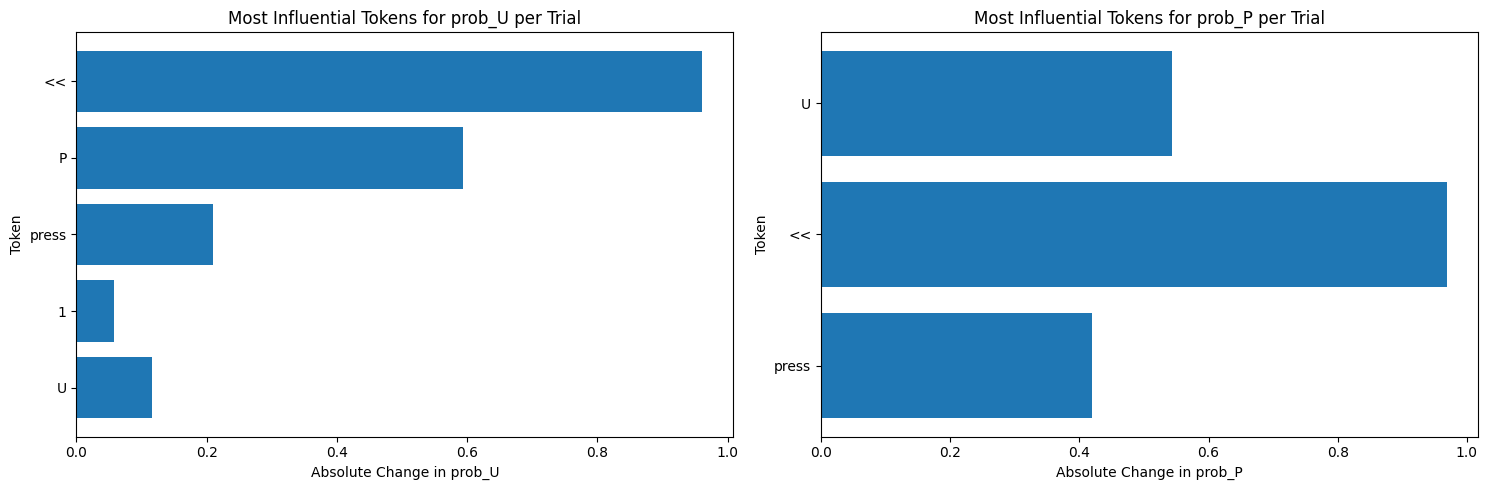

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bar plot showing the magnitude of changes for top influential tokens
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Top tokens by delta_U
ax1.barh(results['max_delta_U_token'], results['max_delta_U'].abs())
ax1.set_xlabel('Absolute Change in prob_U')
ax1.set_ylabel('Token')
ax1.set_title('Most Influential Tokens for prob_U per Trial')
ax1.invert_yaxis()

# Top tokens by delta_P
ax2.barh(results['max_delta_P_token'], results['max_delta_P'].abs())
ax2.set_xlabel('Absolute Change in prob_P')
ax2.set_ylabel('Token')
ax2.set_title('Most Influential Tokens for prob_P per Trial')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()


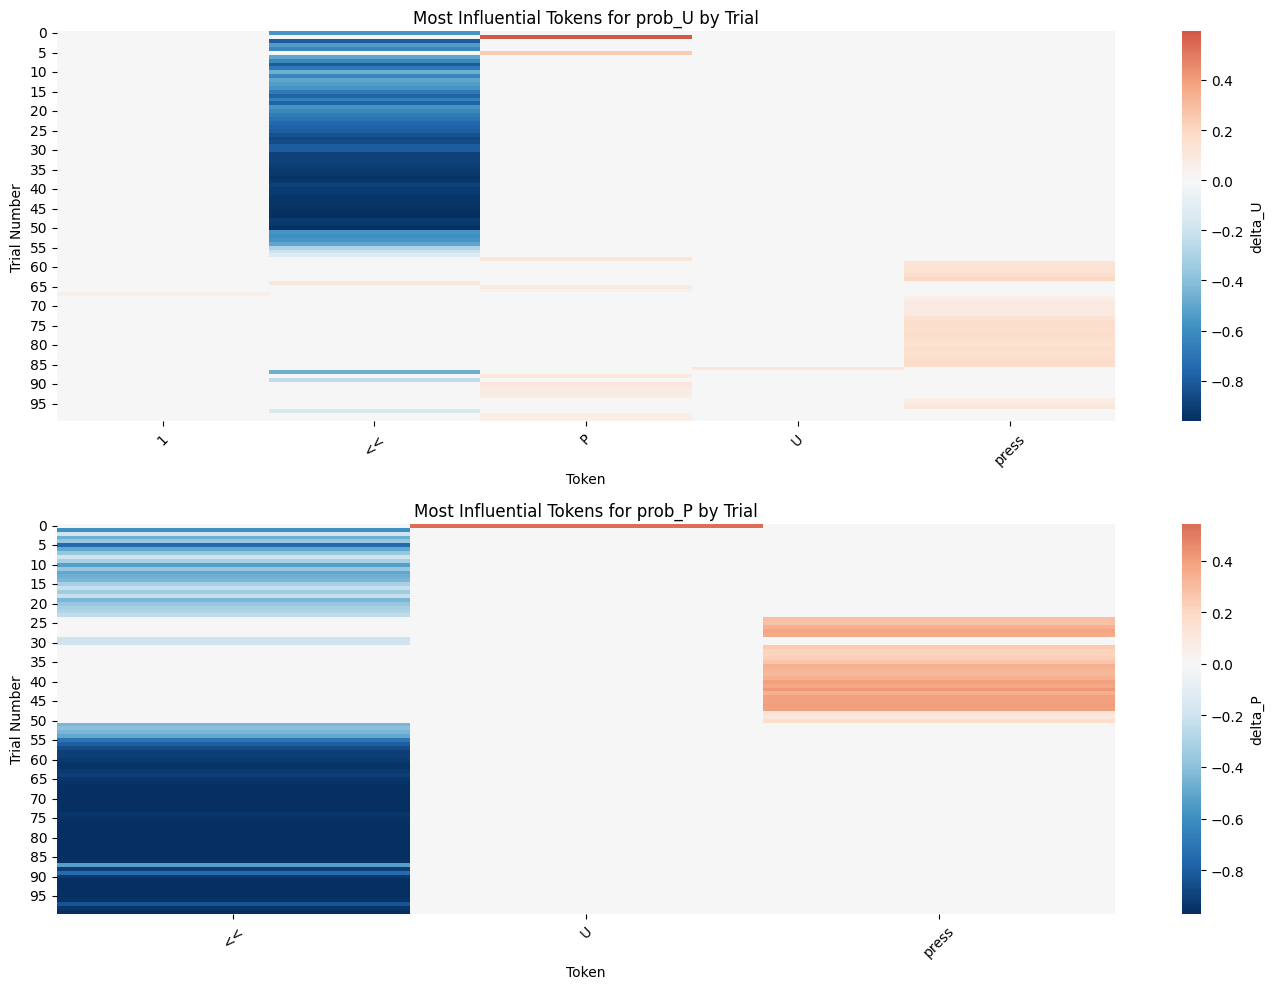

In [23]:
# 2. Heatmap showing position and magnitude of changes with token labels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Create pivot tables for heatmaps with tokens as columns
heatmap_data_U = results[['trial_num', 'max_delta_U_token', 'max_delta_U']].set_index(['trial_num', 'max_delta_U_token'])['max_delta_U'].unstack(fill_value=0)
heatmap_data_P = results[['trial_num', 'max_delta_P_token', 'max_delta_P']].set_index(['trial_num', 'max_delta_P_token'])['max_delta_P'].unstack(fill_value=0)

sns.heatmap(heatmap_data_U, cmap='RdBu_r', center=0, ax=ax1, cbar_kws={'label': 'delta_U'})
ax1.set_title('Most Influential Tokens for prob_U by Trial')
ax1.set_xlabel('Token')
ax1.set_ylabel('Trial Number')
ax1.tick_params(axis='x', rotation=45)

sns.heatmap(heatmap_data_P, cmap='RdBu_r', center=0, ax=ax2, cbar_kws={'label': 'delta_P'})
ax2.set_title('Most Influential Tokens for prob_P by Trial')
ax2.set_xlabel('Token')
ax2.set_ylabel('Trial Number')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

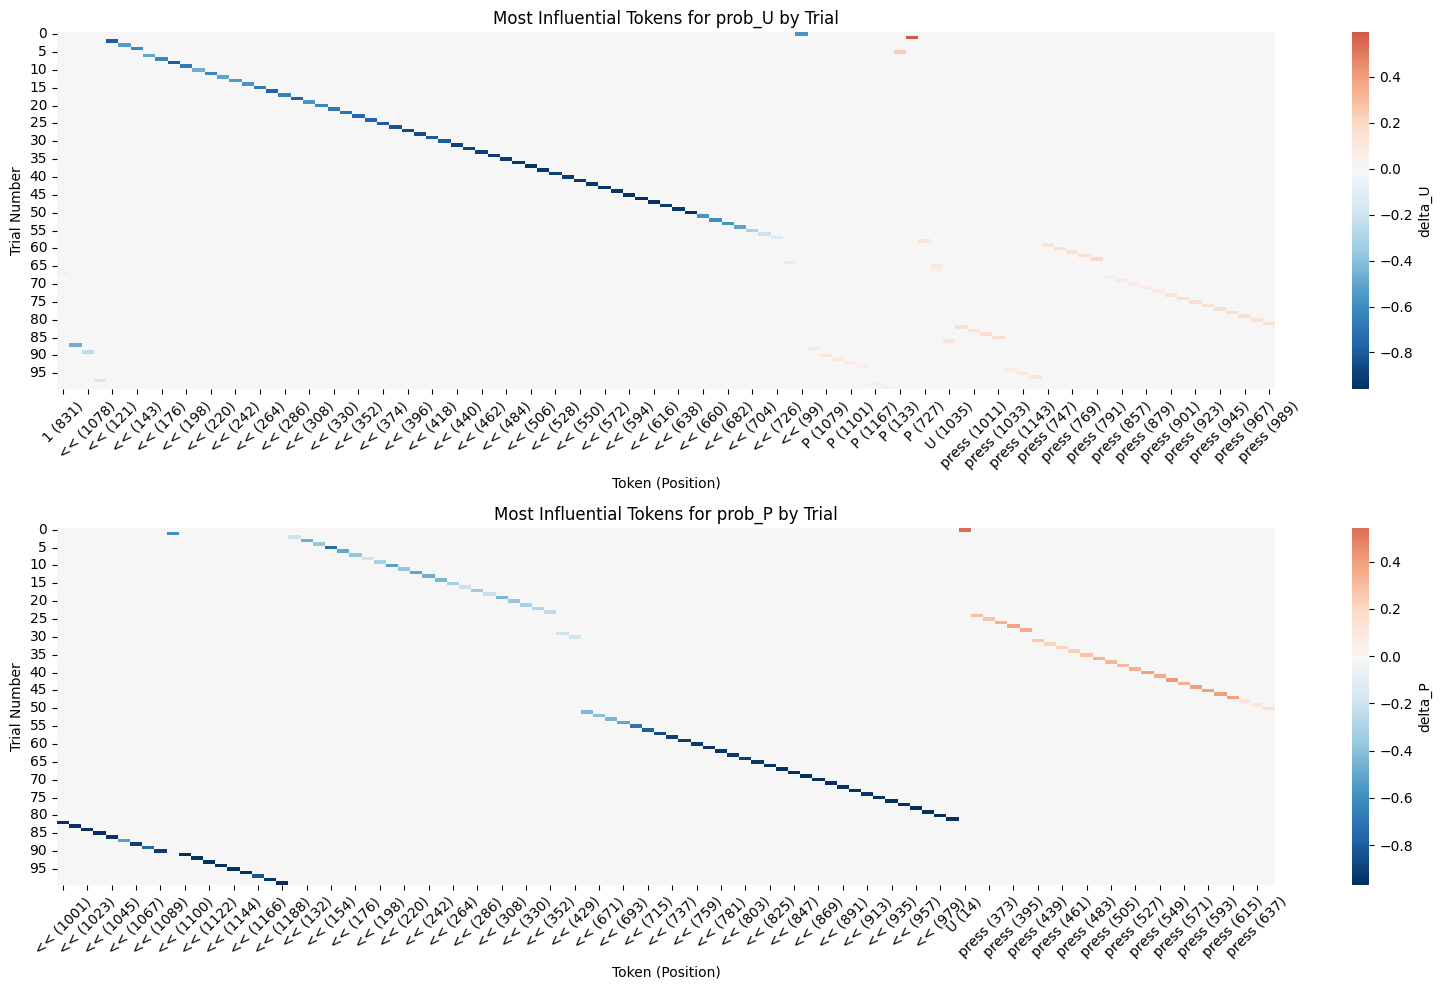

In [25]:
# 2. Heatmap showing position and magnitude of changes with token and position labels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Create combined labels with token and position
results['token_pos_U'] = results['max_delta_U_token'] + ' (' + results['max_delta_U_position'].astype(str) + ')'
results['token_pos_P'] = results['max_delta_P_token'] + ' (' + results['max_delta_P_position'].astype(str) + ')'

# Create pivot tables for heatmaps
heatmap_data_U = results[['trial_num', 'token_pos_U', 'max_delta_U']].set_index(['trial_num', 'token_pos_U'])['max_delta_U'].unstack(fill_value=0)
heatmap_data_P = results[['trial_num', 'token_pos_P', 'max_delta_P']].set_index(['trial_num', 'token_pos_P'])['max_delta_P'].unstack(fill_value=0)

sns.heatmap(heatmap_data_U, cmap='RdBu_r', center=0, ax=ax1, cbar_kws={'label': 'delta_U'})
ax1.set_title('Most Influential Tokens for prob_U by Trial')
ax1.set_xlabel('Token (Position)')
ax1.set_ylabel('Trial Number')
ax1.tick_params(axis='x', rotation=45)

sns.heatmap(heatmap_data_P, cmap='RdBu_r', center=0, ax=ax2, cbar_kws={'label': 'delta_P'})
ax2.set_title('Most Influential Tokens for prob_P by Trial')
ax2.set_xlabel('Token (Position)')
ax2.set_ylabel('Trial Number')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

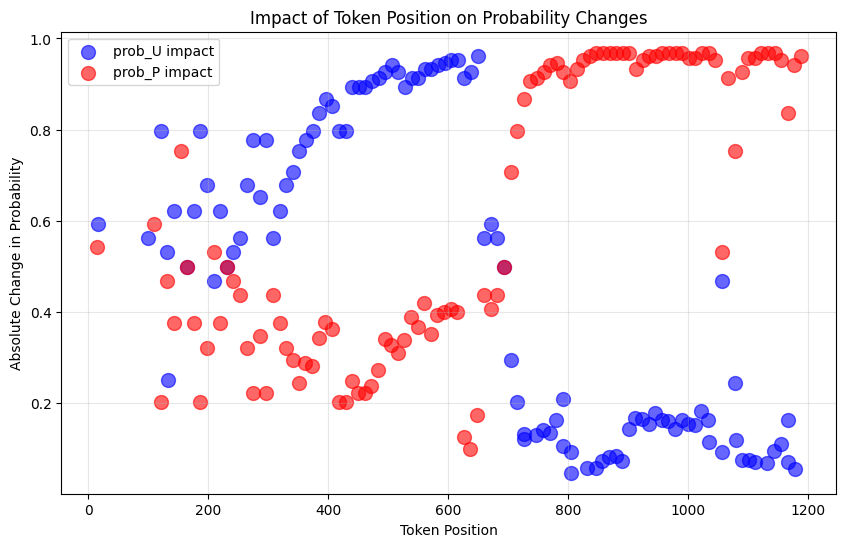

In [17]:
# 3. Scatter plot showing relationship between position and impact
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(results['max_delta_U_position'], results['max_delta_U'].abs(), 
           alpha=0.6, s=100, label='prob_U impact', color='blue')
ax.scatter(results['max_delta_P_position'], results['max_delta_P'].abs(), 
           alpha=0.6, s=100, label='prob_P impact', color='red')

ax.set_xlabel('Token Position')
ax.set_ylabel('Absolute Change in Probability')
ax.set_title('Impact of Token Position on Probability Changes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

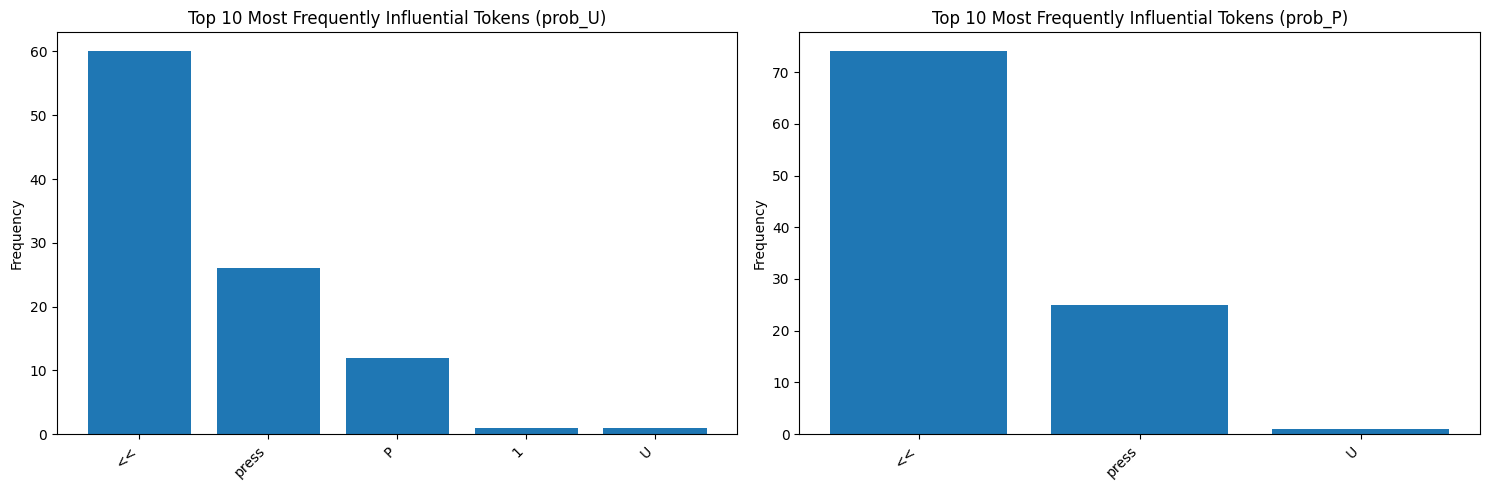

In [18]:
# 4. Word cloud style: Count frequency of most influential tokens
from collections import Counter

token_freq_U = Counter(results['max_delta_U_token'])
token_freq_P = Counter(results['max_delta_P_token'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Most frequent influential tokens for prob_U
tokens_U, counts_U = zip(*token_freq_U.most_common(10))
ax1.bar(range(len(tokens_U)), counts_U)
ax1.set_xticks(range(len(tokens_U)))
ax1.set_xticklabels(tokens_U, rotation=45, ha='right')
ax1.set_ylabel('Frequency')
ax1.set_title('Top 10 Most Frequently Influential Tokens (prob_U)')

# Most frequent influential tokens for prob_P
tokens_P, counts_P = zip(*token_freq_P.most_common(10))
ax2.bar(range(len(tokens_P)), counts_P)
ax2.set_xticks(range(len(tokens_P)))
ax2.set_xticklabels(tokens_P, rotation=45, ha='right')
ax2.set_ylabel('Frequency')
ax2.set_title('Top 10 Most Frequently Influential Tokens (prob_P)')

plt.tight_layout()
plt.show()